## Dijkstra algorithm
Finding the shortest path between two nodes in a graph

### Algorithm Description
Dijkstra's algorithm is a graph search algorithm that solves the single-source shortest path problem for a graph with non-negative edge weights, producing a shortest path tree. This algorithm is often used in routing and as a subroutine in other graph algorithms. It works by iteratively selecting the vertex with the smallest tentative distance from the start vertex, and then exploring its neighbors. The process is repeated until all vertices have been visited, ensuring that the shortest possible path to every vertex from the starting vertex has been found. Named after its creator, Edsger W. Dijkstra, who introduced the algorithm in 1956, it remains a fundamental algorithm in the field of computer science.

In [1]:

import networkx as nx
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from itertools import combinations
import random
import math
import heapq
## make the limit of animation size large
plt.rcParams['animation.embed_limit'] = 50

## Distance function

In [2]:
def dist(p,q):
    return math.sqrt((p[0]-q[0])**2+(p[1]-q[1])**2)

## Distance between sets

In [3]:
def set_dist(X,Y):
    ans=float("inf")
    for x in X:
        for y in Y:
            ans=min(ans,dist(x,y))
    return ans

## Make instances


### Gridgraph with some edges removed and the natural distance

In [4]:
def make_grid_instance(m:int,n:int,p:float):
    """
    Takes two integers, the dimensions of the grid and a probability p that each edge is included
    """
    nodes=[]
    edges=[]
    for i in range(m):
        for j in range(n):
            if np.random.uniform()<p:
                nodes.append((i,j))
    for u,v in combinations(nodes,2):
        if dist(u,v)==1:
            edges.append((u,v))
    G=nx.Graph(edges)
    for u,v in list(G.edges()):
        G[u][v]["weight"]=dist(u,v)
    pos={ place:place for place in list(G.nodes()) }
    ans={"pos":pos,"graph":G}
    return ans




### Random instance

In [5]:
def make_random_instance(m:int,min_dist:float,moat=0.05):
    """
    Generates a set of at most m points in the square (0,1)x(0,1) at distance at 
    least moat and joins them if their distance is less than min_dist
    """
    nodes=[]
    edges=[]
    for i in range(m):
        point=(np.random.uniform(),np.random.uniform())
        if set_dist([point],nodes)>moat:
            nodes.append(point)
    for p,q in combinations(nodes,2):
        if dist(p,q)<min_dist:
            edges.append((p,q))
    G=nx.Graph(edges)
    for u,v in list(G.edges()):
        G[u][v]["weight"]=dist(u,v)
    pos={ place:place for place in list(G.nodes()) }
    ans={"pos":pos,"graph":G}
    return ans

### Dijkstra's algorithm

In [6]:


def dijkstra(graph, start):
    """
    Custom Dijkstra's algorithm implementation.

    Parameters:
    - graph: a networkx graph object
    - start: the starting node

    Returns:
    - distances: a dictionary with the shortest distance from start to every node
    - predecessors: a dictionary with the preceding node in the shortest path
    - visited_nodes: list of nodes visited in the order of visitation
    """
    distances = {node: float('infinity') for node in graph.nodes()}
    distances[start] = 0
    predecessors = {node: None for node in graph.nodes()}
    priority_queue = [(0, start)]
    visited_nodes = []

    while priority_queue:
        current_distance, current_node = heapq.heappop(priority_queue)

        if current_distance > distances[current_node]:
            continue
        
        visited_nodes.append(current_node)

        for neighbor, edge_attributes in graph[current_node].items():
            weight = edge_attributes["weight"]
            distance = current_distance + weight

            if distance < distances[neighbor]:
                distances[neighbor] = distance
                predecessors[neighbor] = current_node
                heapq.heappush(priority_queue, (distance, neighbor))

    return distances, predecessors, visited_nodes

def shortest_path(predecessors, start, end):
    """
    Reconstruct the shortest path from the predecessors.

    Parameters:
    - predecessors: a dictionary with the preceding node in the shortest path
    - start: the starting node
    - end: the ending node

    Returns:
    - path: list of nodes representing the shortest path from start to end
    """
    path = [end]
    while path[-1] != start:
        path.append(predecessors[path[-1]])
    path.reverse()
    return path

## Make frames
Generates a list of pairs of dictionaries with the colors of nodes and edges for each frame

In [7]:
def make_frames_dijkstra(G,start,end):#Takes a networkz graph G,and the starting and ending nodes
    """
    Generates a list of pairs of dictionaries with the colors of nodes and edges for each frame
    """
    distances, predecessors, visited_nodes = dijkstra(G, start)  # Call dijkstra first
    path = shortest_path(predecessors, start,end)
    n=len(path)
    k=visited_nodes.index(end)+1
    visited_nodes=visited_nodes[:k]
    nodes_color_dict={node:"black" for node in list(G.nodes())}
    nodes_color_dict[start]="deeppink"
    nodes_color_dict[end]="palegreen"
    
    edges_color_dict={edge:"black" for edge in list(G.edges())}
    frames=[]
    for node in visited_nodes:
        if node != start:
            nodes_color_dict[node]="deepskyblue" 
        frames.append((nodes_color_dict.copy(),edges_color_dict.copy()))

    for j in range(len(path)-1):
        nodes_color_dict[path[j+1]]="deeppink"
        if (path[j],path[j+1]) in list(G.edges()):
            a,b=path[j],path[j+1]## Make sure the nodes for an edge appear in the right order
        else:
            a,b=path[j+1],path[j]
        edges_color_dict[(a,b)]="deeppink"
        frames.append((nodes_color_dict.copy(),edges_color_dict.copy()))


    return frames

## Same component

In [8]:
def in_same_component(G, node1, node2):
    """
    Check if node1 and node2 are in the same connected component of graph G.
    
    Parameters:
    - G (nx.Graph): The graph.
    - node1: First node.
    - node2: Second node.
    
    Returns:
    - bool: True if node1 and node2 are in the same connected component, False otherwise.
    """
    for component in nx.connected_components(G):
        if node1 in component and node2 in component:
            return True
    return False

## Animate Dijkstra

In [9]:
def animate_dijkstra(Graph,start,end,pos):
    """
    Takes a networkx graph object, the sarting nodes, ending not and the positions dictionary
    """

    if not in_same_component(Graph,start,end):
        return "There is no path joining Start and End"

    G=Graph.copy()
    frames=make_frames_dijkstra(G,start,end)
    #frames=fleury(G)
    pos = pos  # positions for all nodes. There are other possibilities fo layout...
    fig, ax = plt.subplots()
     # format figure
    fig.set_facecolor('cornsilk')
    ax.set_facecolor('cornsilk')
     # List of points
            
    
    
    def update(frame):
        ax.clear()
        node_size={node:100 for node in list(G.nodes())}
        for node in {start,end}:
            node_size[node]=200
        sizes=[node_size[node] for node in list(G.nodes())]

        ax.set_title("Dijkstra's algorithm",color="black",fontsize=18)
        nodes=list(G.nodes())
        a=min([node[0] for node in nodes])
        b=max([node[0] for node in nodes])
        c=min([node[1] for node in nodes])
        d=max([node[1] for node in nodes])
        margin=(b-a)/30

        ax.set_xlim(a-margin,b+margin)   # Setting x-axis limits
        ax.set_ylim(c-margin,d+margin)   # Setting x-axis limits    
        node_colors=[frame[0][node] for node in list(G.nodes())]
        edge_colors=[frame[1][edge] for edge in list(G.edges())]
        nx.draw(G, pos=pos, ax=ax,edge_color=edge_colors,node_color=node_colors,width=2,node_size=sizes)
       
        

    ani = FuncAnimation(fig, update, frames=frames, repeat=True)

    # Convert the animation to a JSHTML representation
    ani_jshtml = ani.to_jshtml()
    #print(frames)
    # Display the animation
    return(HTML(ani_jshtml))

## Animate random instance

In [12]:
ans=make_random_instance(100,0.15)
G=ans["graph"]
pos=ans["pos"]
start=list(G.nodes())[0]
end=list(G.nodes())[60]

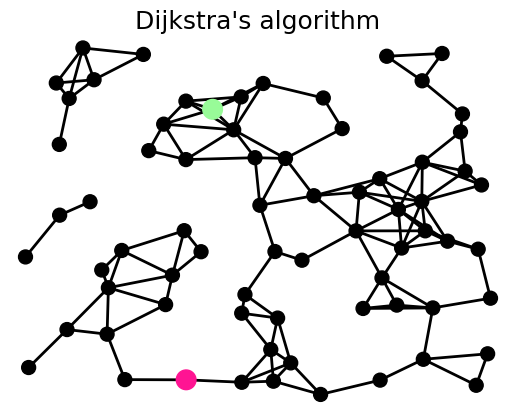

In [13]:
animate_dijkstra(G,start,end,pos)

## Animage Grid Instance

In [16]:
ans=make_grid_instance(10,10,0.7)
G=ans["graph"]
pos=ans["pos"]
start=list(G.nodes())[0]
end=list(G.nodes())[-1]

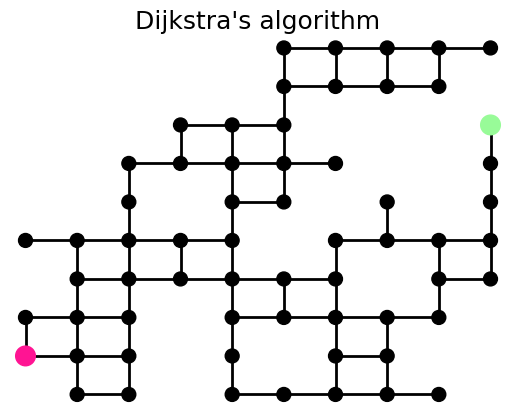

In [17]:
animate_dijkstra(G,start,end,pos)

In [26]:
def Google(l,t):
    ans=[-1,-1]
    n=len(l)
    for i in range(n):
        for j in range(i,n):
            if sum(l[i:j])==t:
                ans=[i,j-1]
    return ans

In [475]:
Google([4,3,10,2,8],12)

[2, 3]